# **Exercício Computacional: PCA e Redução de Dimensionalidade**

## Orientações
- Use `numpy` e `matplotlib`
- Para carregar datasets, você pode usar `sklearn.datasets`
- Complete as partes indicadas
- Interprete os gráficos obtidos
- Responda às perguntas conceituais ao final

Neste exercício, vamos explorar a **Análise de Componentes Principais (PCA)** sob duas perspectivas:
1. **compressão e reconstrução** de imagens de dígitos
2. **visualização em baixa dimensão** de dados tabulares

Usaremos:
- um dataset de dígitos manuscritos (`digits`, com opção de trocar por MNIST)
- um segundo dataset tabular (`wine`)

In [15]:
# Importando bibliotecas

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, load_wine, fetch_openml

np.random.seed(42)

---

## Parte 1 — Carregamento e inspeção inicial dos dados

Nesta parte, vamos carregar um dataset de imagens de dígitos.
Por padrão, use o dataset `digits` do `sklearn`, que é pequeno e estável.

Se desejar, você pode tentar usar o MNIST com `fetch_openml`.
Caso faça isso, recomenda-se trabalhar com um subconjunto dos dados.

In [16]:
# Escolha do dataset de imagens
# Sugestão: comece com USE_MNIST = False
# Se quiser usar MNIST, troque para True

USE_MNIST = False

if USE_MNIST:
    # Dica: depois de carregar, selecione apenas um subconjunto para acelerar a atividade
    X_img, y_img = None, None
else:
    digits = load_digits()
    X_img = digits.data
    y_img = digits.target

print("Formato de X_img:", X_img.shape)
print("Formato de y_img:", y_img.shape)
print("Classes:", np.unique(y_img))

Formato de X_img: (1797, 64)
Formato de y_img: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


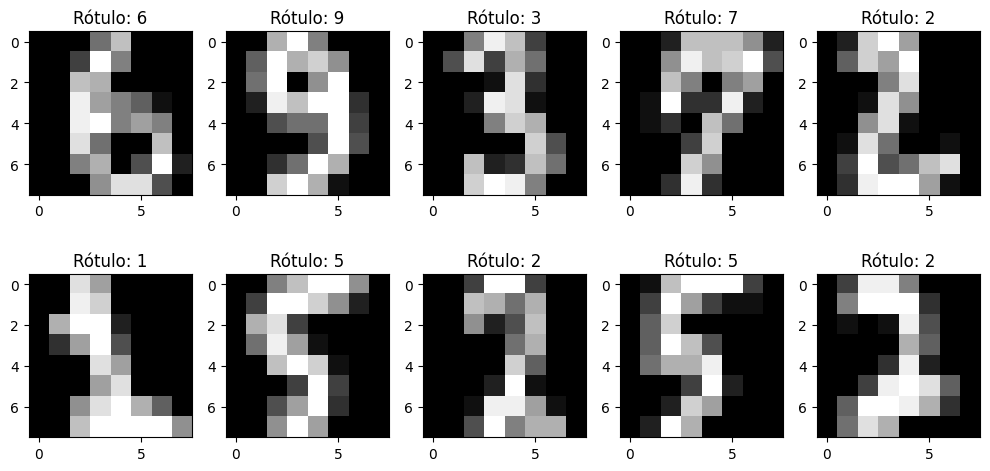

In [17]:
# Visualize algumas imagens do dataset
# Sugestão:
# 1. escolha 10 índices aleatórios
# 2. plote em uma grade 2 x 5
# 3. mostre o rótulo de cada imagem

# Insira seu código aqui
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
indices = np.random.choice(len(X_img), size=10, replace=False)

img_side = int(np.sqrt(X_img.shape[1]))

for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X_img[idx].reshape(img_side, img_side), cmap='gray')
    ax.set_title(f'Rótulo: {y_img[idx]}')

plt.tight_layout()
plt.show()


## Parte 2 — Centralização, padronização opcional e matriz de covariância

Considere uma matriz de dados $\mathbf{X} \in \mathbb{R}^{D \times N}$, em que cada coluna é uma amostra.

Implemente as funções auxiliares:
1. centralização dos dados
2. padronização por desvio padrão
3. matriz de covariância amostral

In [18]:
# Centraliza os dados: subtração da média em cada coluna
def center_data(X):
    mean = np.mean(X, axis=0, keepdims=True)
    X_centered = X - mean
    return X_centered, mean

# Padroniza os dados: divide cada coluna pelo desvio padrão
# Dica: trate o caso de desvio padrão zero
def standardize_data(X):
    std = np.std(X, axis=0, ddof=0, keepdims=True)
    std_safe = np.where(std == 0, 1.0, std) # para tratar as divisoes por zero
    X_standardized = X / std_safe
    return X_standardized, std_safe

# Calcula a matriz de covariância amostral
# Assuma que X já está centrado
def covariance_matrix(X):
    N = X.shape[0]    
    return (X.T @ X) / (N - 1) 

# # covariance_matrix com numpy function
# def covariance_matrix(X):
#     return np.cov(X, rowvar=False)

## Parte 3 — Implementando PCA via autodecomposição

Lembre que, para dados centrados, a PCA pode ser obtida a partir dos autovalores e autovetores da matriz de covariância.

Implemente:
1. uma função `pca_fit`
2. uma função `project_data`
3. uma função `reconstruct_data`
4. uma função para variância explicada acumulada

In [19]:
def pca_fit(X, standardize=False):
    '''
    Entrada:
        X: matriz D x N
        standardize: se True, padroniza além de centralizar

    Saída esperada:
        mean: média das linhas
        scale: desvios-padrão usados na padronização
        eigvals: autovalores em ordem decrescente
        eigvecs: autovetores correspondentes (colunas)
    ''' 
    X_centered, mean = center_data(X)

    if standardize:
        X_proc, scale = standardize_data(X_centered)
    else:
        X_proc = X_centered
        scale = np.ones((1, X.shape[1]))

    C = covariance_matrix(X_proc)

    eigvals, eigvecs = np.linalg.eigh(C)   
  
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    return mean, scale, eigvals, eigvecs

def project_data(X, mean, scale, eigvecs, M):
    '''
    Retorna as projeções z em dimensão M
    '''
    X = np.asarray(X, dtype=float)
    
    X_proc = (X - mean) / scale
    W = eigvecs[:, :M]
    Z = X_proc @ W
    return Z

def reconstruct_data(Z, mean, scale, eigvecs, M):
    '''
    Reconstrói os dados no espaço original
    '''
    W = eigvecs[:, :M]
    X_proc_rec = Z @ W.T # reconstroi
    X_rec = X_proc_rec * scale + mean # desfaz a padronizacao
    return X_rec

def explained_variance_ratio(eigvals):
    '''
    retorna a variancia explicada
    '''
    eigvals = np.asarray(eigvals, dtype=float)
    return np.cumsum(eigvals) / np.sum(eigvals)

## Parte 4 — Ajustando PCA aos dígitos

Nesta parte, ajuste a PCA ao dataset de imagens.

### Tarefas
1. Ajuste a PCA aos dados de imagens
2. Plote os 20 primeiros autovalores
3. Plote a variância explicada acumulada
4. Interprete quantas componentes parecem suficientes para capturar a maior parte da variância

In [20]:
# Ajuste a PCA nos dados de imagens
# Sugestão: comece sem padronização

mean_img, scale_img, eigvals_img, eigvecs_img = pca_fit(X_img, standardize=False)

# Insira seu código aqui
print("Primeiros 20 autovalores:")
print("-"*80)
print(eigvals_img[:20])

print("\nVariância explicada acumulada nas 20 primeiras componentes:")
print("-"*80)
print(explained_variance_ratio(eigvals_img)[:20])


Primeiros 20 autovalores:
--------------------------------------------------------------------------------
[179.0069301  163.71774688 141.78843909 101.1003752   69.51316559
  59.10852489  51.88453911  44.01510667  40.31099529  37.0117984
  28.51904118  27.32116981  21.90148814  21.32435654  17.63672222
  16.94686385  15.85138991  15.00446022  12.23447318  10.88685932]

Variância explicada acumulada nas 20 primeiras componentes:
--------------------------------------------------------------------------------
[0.14890594 0.28509365 0.40303959 0.48713938 0.54496353 0.59413263
 0.6372925  0.67390623 0.70743871 0.73822677 0.76195018 0.78467714
 0.80289578 0.82063433 0.83530534 0.84940249 0.86258838 0.87506976
 0.88524694 0.89430312]


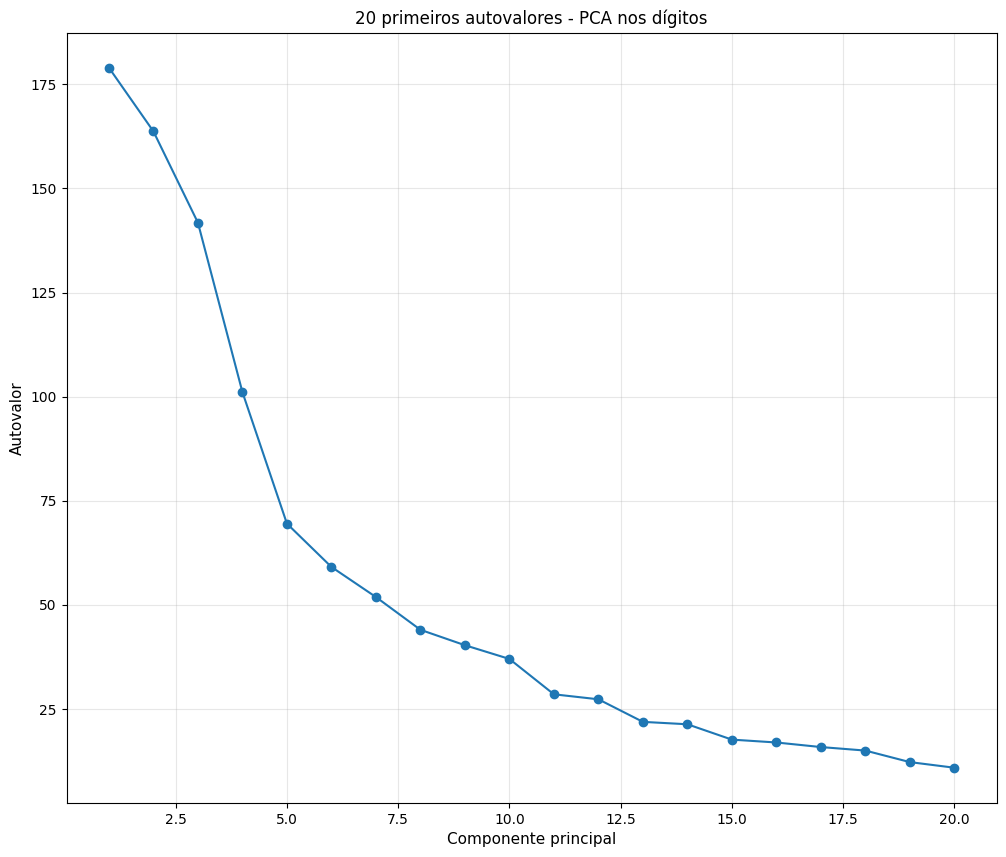

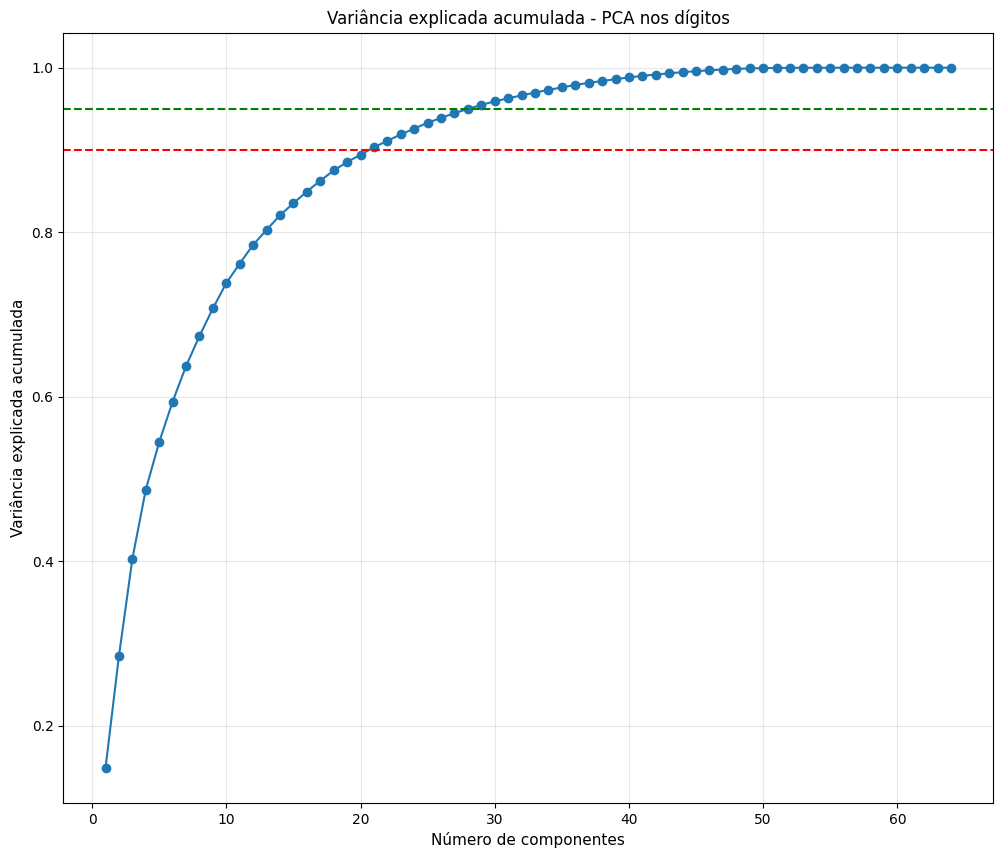

Linha vermelha - Número de componentes para atingir pelo menos 90% da variância: 21
Linha verde - Número de componentes para atingir pelo menos 95% da variância: 29


In [21]:
# Plote:
# 1. os 20 primeiros autovalores
# 2. a variância explicada acumulada

# Insira seu código aqui
# Padronizar estilo do grafico
PLOT_FIGSIZE = (12, 10)
PLOT_MARKERSIZE = 28
PLOT_ALPHA = 0.75
GRID_ALPHA = 0.3

def apply_plot_style(ax, title=None, xlabel=None, ylabel=None, legend=False):
    if title is not None:
        ax.set_title(title, fontsize=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=11)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, alpha=GRID_ALPHA)
    if legend:
        ax.legend(frameon=True)

# Gráfico
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
x_vals = np.arange(1, 21)
ax.plot(x_vals, eigvals_img[:20], marker='o')
apply_plot_style(ax, 
                 title='20 primeiros autovalores - PCA nos dígitos',
                 xlabel='Componente principal', 
                 ylabel='Autovalor')
plt.show()

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
cumvar_img = explained_variance_ratio(eigvals_img)

ax.plot(np.arange(1, len(cumvar_img) + 1), cumvar_img, marker='o')
ax.axhline(0.90, 
           linestyle='--', 
           color="red")
ax.axhline(0.95, 
           linestyle='--', 
           color="green")
apply_plot_style(ax, 
                 title='Variância explicada acumulada - PCA nos dígitos',
                 xlabel='Número de componentes', 
                 ylabel='Variância explicada acumulada')
plt.show()

m90 = np.argmax(cumvar_img >= 0.90) + 1
m95 = np.argmax(cumvar_img >= 0.95) + 1
print(f'Linha vermelha - Número de componentes para atingir pelo menos 90% da variância: {m90}')
print(f'Linha verde - Número de componentes para atingir pelo menos 95% da variância: {m95}')

## Parte 5 — Visualização em 2D dos dígitos

Projete os dados no subespaço gerado pelas duas primeiras componentes principais.

### Tarefas
1. Obtenha a projeção 2D
2. Faça um scatter plot
3. Colora os pontos de acordo com o rótulo
4. Comente se algumas classes parecem mais separadas do que outras

<Figure size 1200x1000 with 0 Axes>

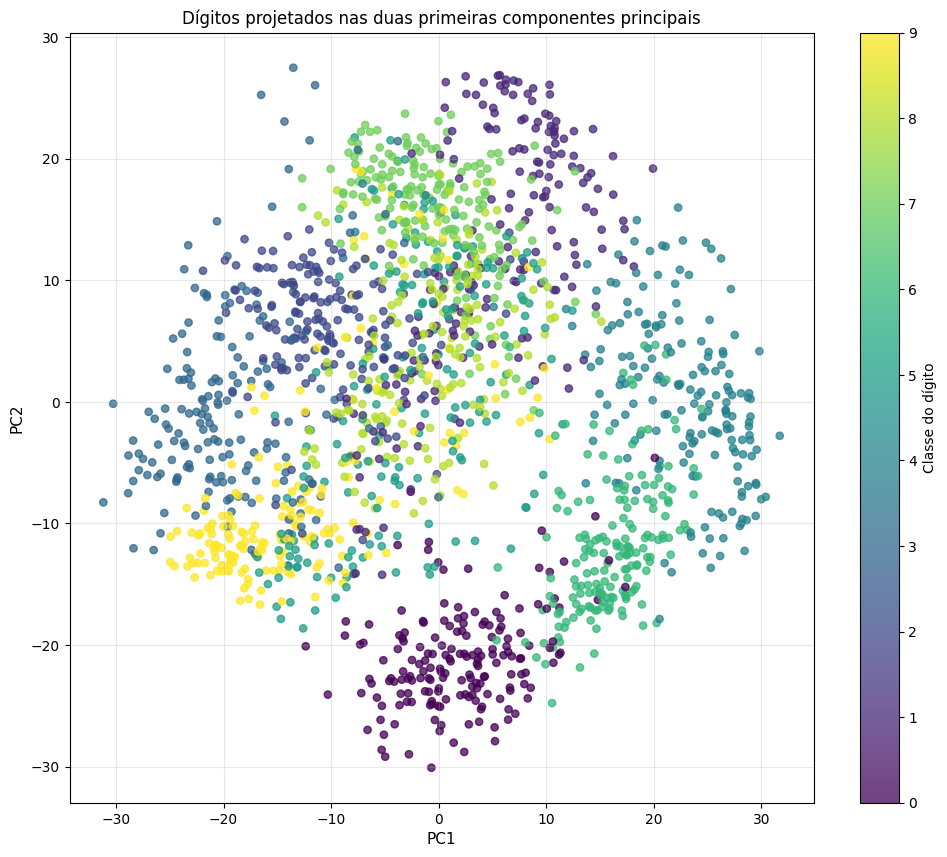

In [22]:
# Projeção em 2D do dataset de imagens

Z2_img = project_data(X_img, mean_img, scale_img, eigvecs_img, M=2)

# Insira seu código aqui

plt.figure(figsize=(12, 10))
# Insira seu código do scatter aqui
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
scatter = ax.scatter(Z2_img[:, 0], 
                     Z2_img[:, 1], 
                     c=y_img, 
                     s=PLOT_MARKERSIZE, 
                     alpha=PLOT_ALPHA)
apply_plot_style(ax,
                 title='Dígitos projetados nas duas primeiras componentes principais',
                 xlabel='PC1', 
                 ylabel='PC2')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Classe do dígito')
plt.show()

## Parte 6 — Reconstrução de imagens com poucas componentes

Agora vamos usar PCA como técnica de compressão.

### Tarefas
1. Escolha uma imagem do dataset
2. Reconstrua essa imagem usando \(M = 2, 5, 10, 20, 40\) componentes
3. Compare visualmente as reconstruções
4. Comente o efeito do aumento de \(M\)

In [23]:
# Escolha uma imagem para reconstruir
idx = 0
x0 = X_img[idx:idx+1]

Ms = [2, 5, 10, 20, 40]

# Insira seu código aqui para projetar e reconstruir x0 para diferentes M

# Dica:
# para digits, a imagem é 8x8
# para MNIST, a imagem é 28x28

img_side = int(np.sqrt(X_img.shape[1]))
reconstructions = {}

for M in Ms:
    z0 = project_data(x0, mean_img, scale_img, eigvecs_img, M=M)
    x0_rec = reconstruct_data(z0, mean_img, scale_img, eigvecs_img, M=M)
    reconstructions[M] = x0_rec

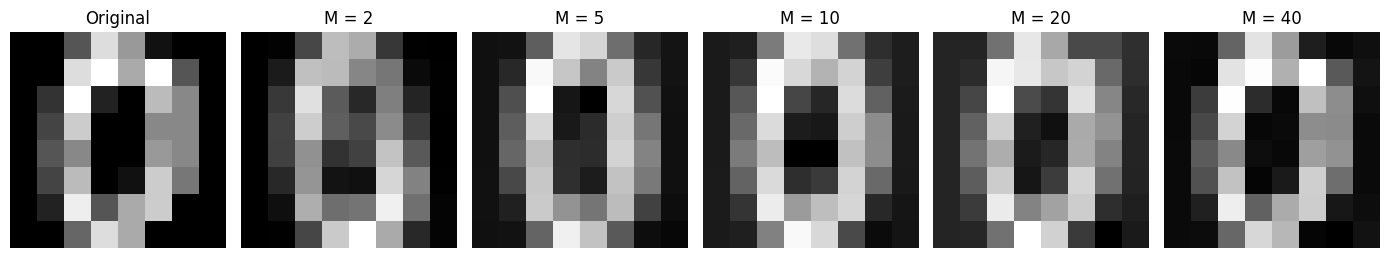

In [24]:
# Plote a imagem original e as reconstruções lado a lado

# Insira seu código aqui
fig, axes = plt.subplots(1, len(Ms) + 1, figsize=(14, 3))

axes[0].imshow(x0.reshape(img_side, img_side), cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for ax, M in zip(axes[1:], Ms):
    ax.imshow(reconstructions[M].reshape(img_side, img_side), cmap='gray')
    ax.set_title(f'M = {M}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Parte 7 — Erro de reconstrução médio

Vamos quantificar a compressão.

### Tarefas
1. Para \(M = 1, 2, 5, 10, 20, 40\), calcule a reconstrução de todo o dataset
2. Calcule o erro quadrático médio de reconstrução
3. Plote erro de reconstrução em função de \(M\)
4. Interprete o comportamento observado

In [25]:
def reconstruction_mse(X, X_rec):
    return np.mean((X - X_rec) ** 2)

Ms = [1, 2, 5, 10, 20, 40]
mse_values = []

# Insira seu código aqui
for M in Ms:
    Z = project_data(X_img, mean_img, scale_img, eigvecs_img, M=M)
    X_rec = reconstruct_data(Z, mean_img, scale_img, eigvecs_img, M=M)
    mse = reconstruction_mse(X_img, X_rec)
    mse_values.append(mse)
    print(f'M = {M:2d} | MSE de reconstrução = {mse:.4f}')


M =  1 | MSE de reconstrução = 15.9777
M =  2 | MSE de reconstrução = 13.4210
M =  5 | MSE de reconstrução = 8.5424
M = 10 | MSE de reconstrução = 4.9143
M = 20 | MSE de reconstrução = 1.9843
M = 40 | MSE de reconstrução = 0.2215


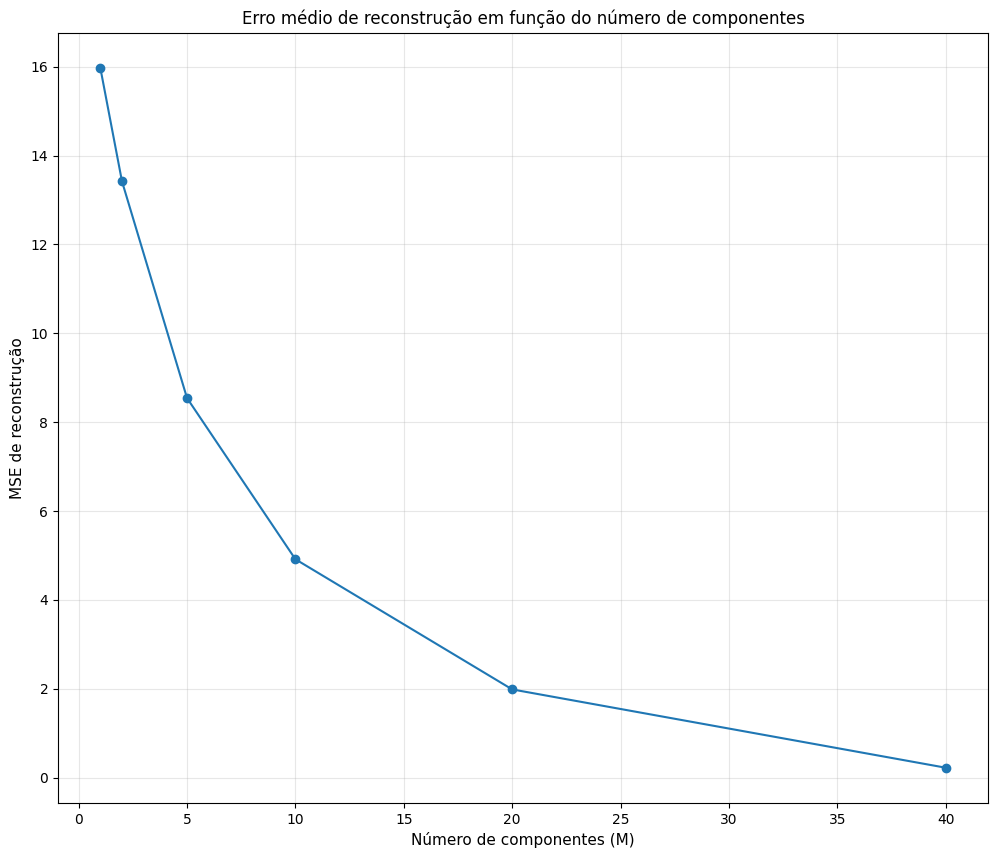

In [26]:
# Plote o erro de reconstrução em função de M

# Insira seu código aqui
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
ax.plot(Ms, mse_values, marker='o')
apply_plot_style(ax,
                 title='Erro médio de reconstrução em função do número de componentes',
                 xlabel='Número de componentes (M)',
                 ylabel='MSE de reconstrução')
plt.show()

## Parte 8 — Segundo dataset: Wine

Agora vamos aplicar PCA a um dataset tabular com poucas dimensões,
para visualizar como a PCA pode ajudar na separação de classes.

### Tarefas
1. Carregue o dataset `wine`
2. Aplique PCA com padronização
3. Projete os dados em 2D
4. Faça um scatter plot colorido pelas classes
5. Compare com a visualização nas duas primeiras features originais

In [27]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print("Formato de X_wine:", X_wine.shape)
print("Classes:", np.unique(y_wine))
print("Nomes das features:", wine.feature_names)

Formato de X_wine: (178, 13)
Classes: [0 1 2]
Nomes das features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


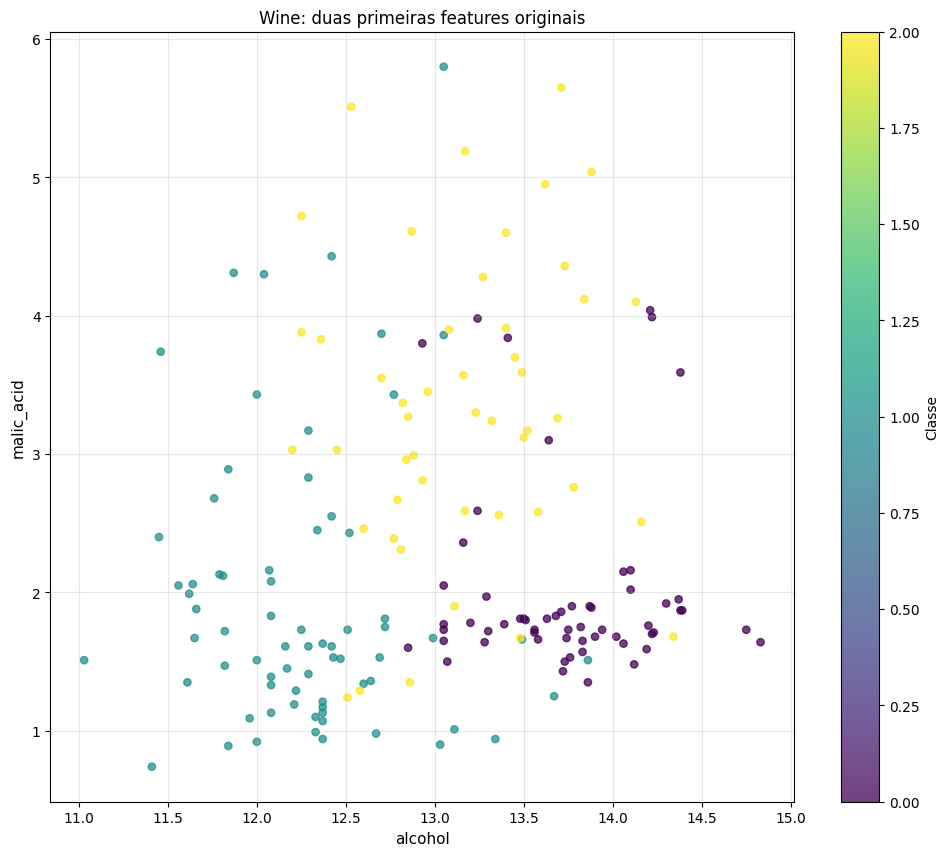

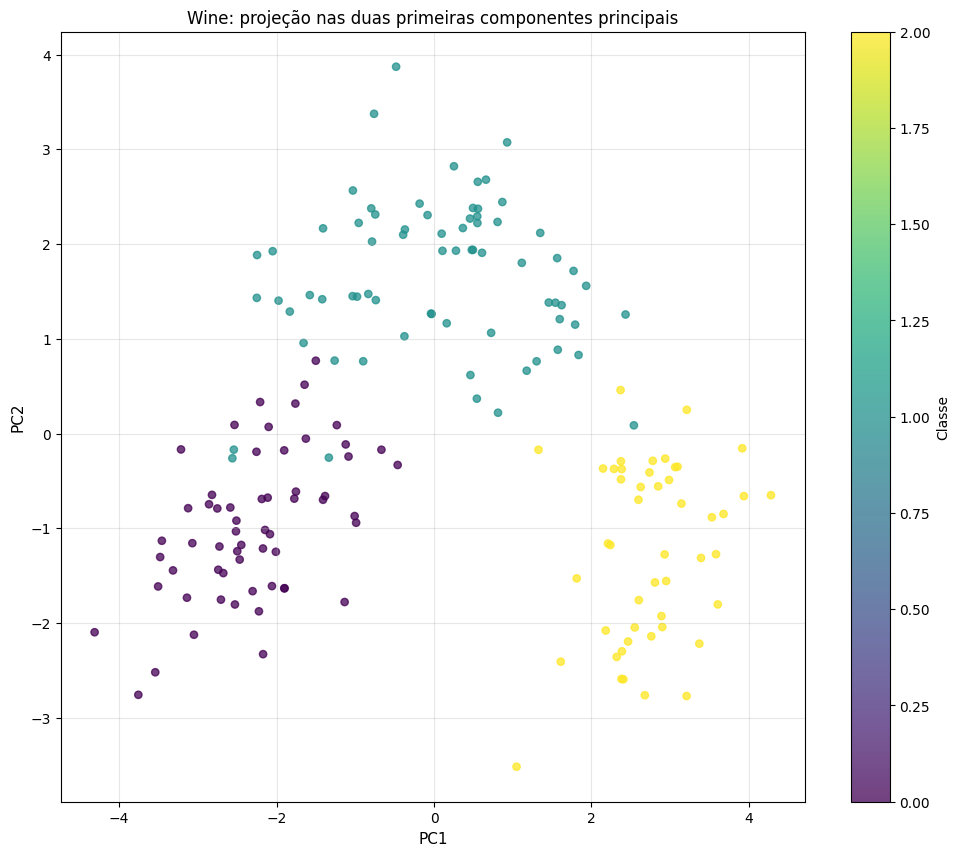

Variância explicada acumulada nas duas primeiras PCs: 0.5540633835693527


In [28]:
# Compare:
# 1. scatter usando as duas primeiras features originais
# 2. scatter usando as duas primeiras componentes principais

# Insira seu código aqui
mean_wine, scale_wine, eigvals_wine, eigvecs_wine = pca_fit(X_wine, standardize=True)
Z2_wine = project_data(X_wine, mean_wine, scale_wine, eigvecs_wine, M=2)

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
scatter1 = ax.scatter(X_wine[:, 0], X_wine[:, 1], c=y_wine, s=PLOT_MARKERSIZE, alpha=PLOT_ALPHA)
apply_plot_style(ax,
                 title='Wine: duas primeiras features originais',
                 xlabel=wine.feature_names[0],
                 ylabel=wine.feature_names[1])
cbar1 = plt.colorbar(scatter1, ax=ax)
cbar1.set_label('Classe')
plt.show()

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
scatter2 = ax.scatter(Z2_wine[:, 0], Z2_wine[:, 1], c=y_wine, s=PLOT_MARKERSIZE, alpha=PLOT_ALPHA)
apply_plot_style(ax,
                 title='Wine: projeção nas duas primeiras componentes principais',
                 xlabel='PC1',
                 ylabel='PC2')
cbar2 = plt.colorbar(scatter2, ax=ax)
cbar2.set_label('Classe')
plt.show()

print("Variância explicada acumulada nas duas primeiras PCs:",
      explained_variance_ratio(eigvals_wine)[1])

## Parte 9 — Questões conceituais

Responda:

1. Por que é importante centralizar os dados antes de aplicar PCA?
2. Em que situação a padronização é especialmente importante?
3. O que representam os autovalores na PCA?
4. O que significa dizer que PCA realiza uma aproximação de baixo posto?
5. Por que a reconstrução melhora quando aumentamos o número de componentes?
6. A PCA é supervisionada ou não supervisionada?
7. Por que a PCA pode ajudar na visualização, mas nem sempre separar perfeitamente as classes?

Respostas:

1. Centralizar os dados é importante porque a PCA analisa a variabilidade em torno da média. Sem isso, a analise pode capturar a posição dos dados, e não sua estrutura real.

2. A padronização é especialmente importante quando as variáveis estão em escalas diferentes, porque evita que variáveis com valores maiores influenciem a PCA.

3. Na PCA, os autovalores representam a variância de cada componente principal. Ou seja, quanto maior o autovalor, mais importante é aquele componente para representar os dados.

4. Como o posto de uma matriz corresponde ao número máximo de colunas linearmente independentes, dizer que a PCA realiza uma aproximação de baixo posto significa que ela substitui a matriz original por uma aproximação construída a partir de um número menor de componentes principais. Embora essa matriz aproximada possa manter as mesmas dimensões da matriz original, ela passa a ter menor posto, pois sua variabilidade é descrita por menos direções independentes.

5. A reconstrução melhora quando aumentamos o número de componentes porque ao aumentar o número de componentes também há um aumento na variância explicada, ou seja, aumenta a quantidade de informação da matriz original.

6. A PCA é um método não supervisionado.

7. A PCA pode auxiliar na visualização dos dados porque concentra grande parte da variabilidade total em apenas 2 ou 3 dimensões, o que facilita sua representação gráfica. No entanto, seu objetivo principal é encontrar combinações lineares que maximizem a variância dos dados em um espaço de menor dimensionalidade do que o espaço original, e não maximizar a separação entre classes. Por isso, embora a PCA possa revelar padrões e agrupamentos, ela não garante uma separação perfeita entre grupos distintos.